In [11]:
"""
Imports
"""

import laspy
import open3d as o3d
import numpy as np
import pyntcloud
from pyntcloud import PyntCloud
import pandas as pd

In [12]:
"""
Variables and filepaths 
"""

final_project_segment_file = "final_project_segment.laz"


In [13]:
def read_las_points(filepath):
    las = laspy.read(filepath)
    points = np.vstack((las.x, las.y, las.z)).T
    return las, points

In [14]:
las, points = read_las_points(final_project_segment_file)
print("Number of points: ", len(las.points))

Number of points:  1988927


In [15]:
"""
2. Outlier removal (Statistical)
"""
# Konverter til Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Fjern uteliggere: 10 naboer, fjern punkter som ligger > 5 std-avvik fra snittet
cl, ind = pcd.remove_statistical_outlier(nb_neighbors=50, std_ratio=5.0)

# Behold kun punktene som ikke ble fjernet
pcd_filtered = pcd.select_by_index(ind)
print(f"Removed {len(points) - len(ind):,} outlier points")
print(f"Remaining points after filtering: {len(ind):,}")

# Konverter tilbake til numpy-array
points_filtered = np.asarray(pcd_filtered.points)

"""
3. Create PyntCloud object from filtered points
"""
# Lag dataframe for PyntCloud
df = pd.DataFrame(points_filtered, columns=["x", "y", "z"])
cloud = PyntCloud(df)

"""
4. Voxelization
"""
voxel_size = 2  # meter
voxelgrid_id = cloud.add_structure("voxelgrid",
                                   size_x=voxel_size,
                                   size_y=voxel_size,
                                   size_z=voxel_size)
voxelgrid = cloud.structures[voxelgrid_id]

num_voxels = len(voxelgrid.voxel_n)
print(f"Total voxels created: {num_voxels:,}")

"""
5. Filter out voxels with fewer than 10 points
"""
valid_voxel_mask = voxelgrid.voxel_n > 10
valid_voxel_indices = np.where(valid_voxel_mask)[0]
num_valid_voxels = len(valid_voxel_indices)
print(f"Voxels with >=10 points: {num_valid_voxels:,}")

"""
6. Create a filtered point cloud with only points from valid voxels (manual mapping)
"""
# Finn min- og makskoordinater for punktene
min_coords = np.floor(points_filtered.min(axis=0))
max_coords = np.ceil(points_filtered.max(axis=0))

# Beregn hvor mange voxler vi har i hver retning (avrundet opp)
dims = np.ceil((max_coords - min_coords) / voxel_size).astype(int)

# Beregn hvilken voxel hvert punkt tilhører
coords = np.floor((points_filtered - min_coords) / voxel_size).astype(int)

# Sørg for at alle punkter havner innenfor gridet
coords = np.clip(coords, 0, dims - 1)

# Gi hvert punkt et unikt voxel-ID
voxel_ids = np.ravel_multi_index((coords[:,0], coords[:,1], coords[:,2]), dims=dims)

# Tell hvor mange punkter hver voxel inneholder
unique_ids, counts = np.unique(voxel_ids, return_counts=True)
voxel_count_dict = dict(zip(unique_ids, counts))

# Filtrer bort punkter som ligger i voxler med færre enn 10 punkter
mask_valid = np.array([voxel_count_dict.get(i, 0) >= 10 for i in voxel_ids])
filtered_points_final = points_filtered[mask_valid]

print(f"Points after voxel filtering: {filtered_points_final.shape[0]:,}")
print(f"Kept {(filtered_points_final.shape[0] / len(points_filtered)) * 100:.2f}% of points after voxel filtering")
 
"""
7. Save or visualize (optional)
"""
# Lag nytt Open3D-punktcloud for visning
pcd_voxel_filtered = o3d.geometry.PointCloud()
pcd_voxel_filtered.points = o3d.utility.Vector3dVector(filtered_points_final)

# Visualiser
o3d.visualization.draw_geometries([pcd_voxel_filtered])
unique_voxel_ids = np.unique(voxel_ids)

print("Unique occupied voxels:", len(unique_voxel_ids))
print(f"Removed {len(points) - len(ind)} outliers ({(len(points) - len(ind))/len(points)*100:.3f}%)")



Removed 10,550 outlier points
Remaining points after filtering: 1,978,377
Total voxels created: 1,978,377
Voxels with >=10 points: 1,978,377
Points after voxel filtering: 1,950,756
Kept 98.60% of points after voxel filtering
Unique occupied voxels: 33320
Removed 10550 outliers (0.530%)


In [16]:
from sklearn.decomposition import PCA

# 1️⃣ Samle punkter per voxel
voxel_ids_filtered = voxel_ids[mask_valid]
unique_voxel_ids = np.unique(voxel_ids_filtered)

voxel_features = []

for voxel_id in unique_voxel_ids:
    voxel_points = filtered_points_final[voxel_ids_filtered == voxel_id]
    
    # Hopper over små voxler (sikkerhetsmargin)
    if len(voxel_points) < 10:
        continue

    # 2️⃣ PCA på punktene
    pca = PCA(n_components=3)
    pca.fit(voxel_points)
    eigenvalues = np.sort(pca.explained_variance_)[::-1]  # sortert: λ1 ≥ λ2 ≥ λ3

    λ1, λ2, λ3 = eigenvalues
    if λ1 == 0:
        continue

    # 3️⃣ Beregn features
    linearity = (λ1 - λ2) / λ1
    planarity = (λ2 - λ3) / λ1
    scattering = λ3 / λ1
    omnivariance = (λ1 * λ2 * λ3) ** (1/3)
    sum_ev = λ1 + λ2 + λ3
    anisotropy = (λ1 - λ3) / λ1
    eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
    change_curvature = λ3 / (λ1 + λ2 + λ3)

    # 4️⃣ Ikke-PCA features
    z_range = voxel_points[:,2].max() - voxel_points[:,2].min()

    # Standard deviation from local plane = std i z-retning etter PCA
    plane_std = np.std(pca.transform(voxel_points)[:, 2])

    # Lagre alt i én dictionary
    voxel_features.append({
        "voxel_id": voxel_id,
        "n_points": len(voxel_points),
        "linearity": linearity,
        "planarity": planarity,
        "scattering": scattering,
        "omnivariance": omnivariance,
        "sum_ev": sum_ev,
        "anisotropy": anisotropy,
        "eigentropy": eigentropy,
        "change_curvature": change_curvature,
        "z_range": z_range,
        "plane_std": plane_std
    })

print(f"Calculated features for {len(voxel_features)} voxels")


C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: RuntimeWarning: divide by zero encountered in log
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: RuntimeWarning: invalid value encountered in scalar multiply
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: RuntimeWarning: divide by zero encountered in log
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: RuntimeWarning: invalid value encountered in scalar multiply
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: RuntimeWarning: divide by zero encountered in log
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: 

Calculated features for 26617 voxels


C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: RuntimeWarning: divide by zero encountered in log
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2844560819.py:32: RuntimeWarning: invalid value encountered in scalar multiply
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))


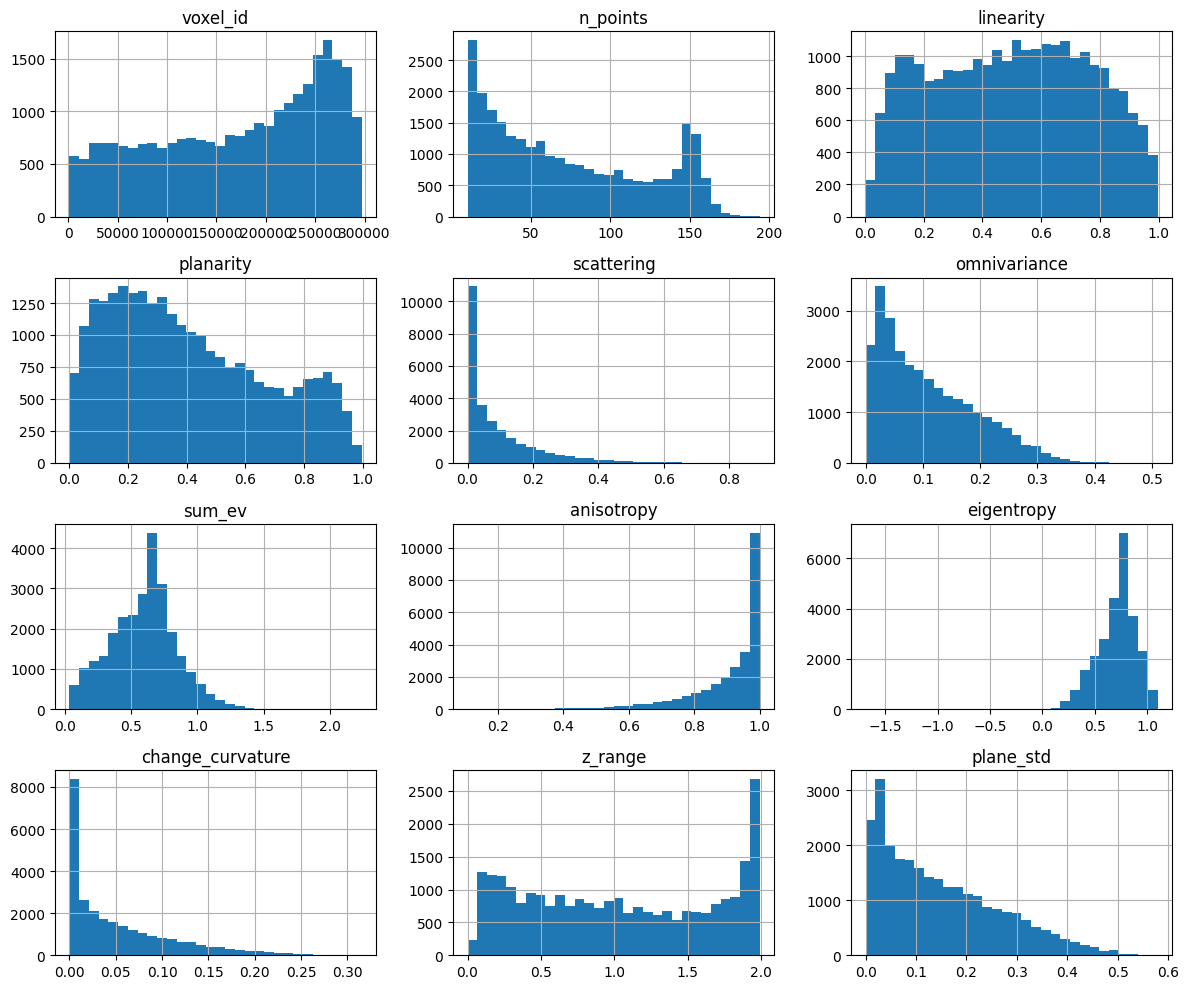

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df_features = pd.DataFrame(voxel_features)

# Lag histogram for hver feature
df_features.hist(bins=30, figsize=(12,10))
plt.tight_layout()
plt.show()


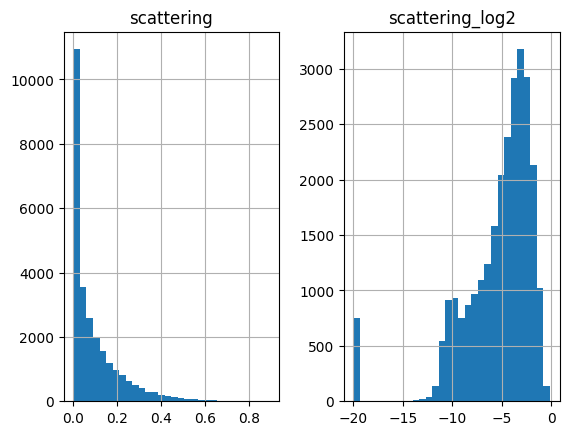

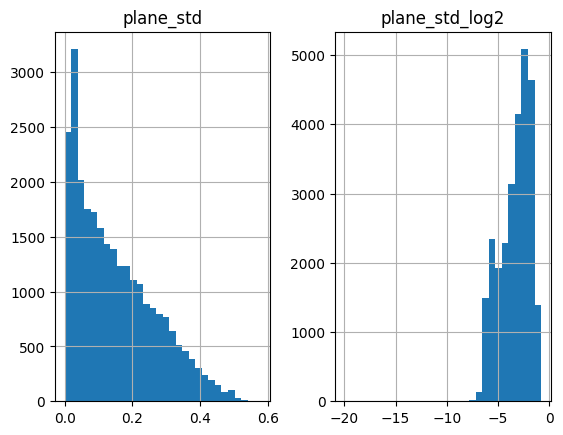

In [18]:
import numpy as np

df_features["scattering_log2"] = np.log2(df_features["scattering"] + 1e-6)
df_features["plane_std_log2"] = np.log2(df_features["plane_std"] + 1e-6)

df_features[["scattering", "scattering_log2"]].hist(bins=30)
df_features[["plane_std", "plane_std_log2"]].hist(bins=30)
plt.show()


In [19]:
"""
Save voxel centers as .las for visualization in CloudCompare
"""

import laspy

# Beregn senterkoordinat for hver voxel (for visualisering)
voxel_centers = []
for voxel_id in unique_voxel_ids:
    voxel_points = filtered_points_final[voxel_ids_filtered == voxel_id]
    center = voxel_points.mean(axis=0)
    voxel_centers.append(center)

voxel_centers = np.array(voxel_centers)

# Lagre som .las slik at du kan åpne i CloudCompare
header = laspy.LasHeader(point_format=3, version="1.2")
las = laspy.LasData(header)
las.x, las.y, las.z = voxel_centers[:,0], voxel_centers[:,1], voxel_centers[:,2]
las.write("voxel_centers.las")

print(len(voxel_centers), "voxel centers saved to voxel_centers.las")

print("✅ Saved voxel centers to voxel_centers.las")

26617 voxel centers saved to voxel_centers.las
✅ Saved voxel centers to voxel_centers.las


In [20]:
def read_las_coords(filepath):
    las = laspy.read(filepath)
    return np.vstack((las.x, las.y, las.z)).T

buildings = read_las_coords("voxel_centers_building.las")
trees = read_las_coords("voxel_centers_trees.las")
terrain = read_las_coords("voxel_centers_terrain.las")

def find_nearest_voxel_ids(coords, voxel_centers, voxel_ids):
    from scipy.spatial import cKDTree
    tree = cKDTree(voxel_centers)
    _, idx = tree.query(coords, k=1)
    return np.array(voxel_ids)[idx]

building_ids = find_nearest_voxel_ids(buildings, voxel_centers, unique_voxel_ids)
tree_ids = find_nearest_voxel_ids(trees, voxel_centers, unique_voxel_ids)
terrain_ids = find_nearest_voxel_ids(terrain, voxel_centers, unique_voxel_ids)

df_features["label"] = "unlabeled"
df_features.loc[df_features["voxel_id"].isin(building_ids), "label"] = "building"
df_features.loc[df_features["voxel_id"].isin(tree_ids), "label"] = "tree"
df_features.loc[df_features["voxel_id"].isin(terrain_ids), "label"] = "terrain"

train_df = df_features[df_features["label"] != "unlabeled"]
print(train_df["label"].value_counts())

train_df.to_csv("voxel_features_labeled.csv", index=False)
print("✅ Labeled training data saved to voxel_features_labeled.csv")


label
tree        1274
building     193
terrain      147
Name: count, dtype: int64
✅ Labeled training data saved to voxel_features_labeled.csv


In [29]:
"""
Feature Analysis – PCA-baserte 3D-features per voxel
Author: Åsne Haavengen
"""

# -------------------- Imports --------------------
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import open3d as o3d

# -------------------- 1. Forutsetning --------------------
# Denne koden forutsetter at du allerede har gjort:
#  - Outlier removal
#  - Voxelization
# og at du har følgende variabler klare:
#     points_filtered        (etter uteligger-fjerning)
#     voxel_ids              (tilordnet hvert punkt)
#     mask_valid             (True for punkter i voxler med ≥10 punkter)

# -------------------- 2. Filtrér punkter og voxel-IDer --------------------
filtered_points_final = points_filtered[mask_valid]
voxel_ids_filtered = voxel_ids[mask_valid]

print(f"Points after voxel filtering: {filtered_points_final.shape[0]:,}")
print(f"Unique voxels after filtering: {len(np.unique(voxel_ids_filtered)):,}")

# 💾 LAGRE til bruk i neste steg (klassifisering)
np.save("filtered_points_final.npy", filtered_points_final)
np.save("voxel_ids_filtered.npy", voxel_ids_filtered)
print("✅ Saved filtered_points_final.npy and voxel_ids_filtered.npy")

# -------------------- 3. Beregn PCA-features per voxel --------------------
voxel_features = []
unique_voxel_ids = np.unique(voxel_ids_filtered)

for voxel_id in unique_voxel_ids:
    voxel_points = filtered_points_final[voxel_ids_filtered == voxel_id]
    if len(voxel_points) < 10:
        continue

    # PCA
    pca = PCA(n_components=3)
    pca.fit(voxel_points)
    eigenvalues = np.sort(pca.explained_variance_)[::-1]
    λ1, λ2, λ3 = eigenvalues
    if λ1 == 0:
        continue

    # PCA-baserte features
    linearity = (λ1 - λ2) / λ1
    planarity = (λ2 - λ3) / λ1
    scattering = λ3 / λ1
    omnivariance = (λ1 * λ2 * λ3) ** (1/3)
    sum_ev = λ1 + λ2 + λ3
    anisotropy = (λ1 - λ3) / λ1
    eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
    change_curvature = λ3 / (λ1 + λ2 + λ3)

    # Ikke-PCA-baserte
    z_range = voxel_points[:, 2].max() - voxel_points[:, 2].min()
    plane_std = np.std(pca.transform(voxel_points)[:, 2])

    voxel_features.append({
        "voxel_id": voxel_id,
        "n_points": len(voxel_points),
        "linearity": linearity,
        "planarity": planarity,
        "scattering": scattering,
        "omnivariance": omnivariance,
        "sum_ev": sum_ev,
        "anisotropy": anisotropy,
        "eigentropy": eigentropy,
        "change_curvature": change_curvature,
        "z_range": z_range,
        "plane_std": plane_std
    })

print(f"✅ Calculated features for {len(voxel_features)} voxels")

# -------------------- 4. Lag DataFrame --------------------
df_features = pd.DataFrame(voxel_features)
df_features.to_csv("voxel_features_all.csv", index=False)
print("💾 Saved voxel_features_all.csv")

# -------------------- 5. Beregn voxel-sentre i samme rekkefølge --------------------
voxel_centers = []
for voxel_id in df_features["voxel_id"].values:
    pts = filtered_points_final[voxel_ids_filtered == voxel_id]
    voxel_centers.append(pts.mean(axis=0))

voxel_centers = np.array(voxel_centers)
np.save("voxel_centers.npy", voxel_centers)
print(f"💾 Saved voxel_centers.npy for {len(voxel_centers)} voxels")

# -------------------- 6. Visualiser (valgfritt) --------------------
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(voxel_centers)
o3d.visualization.draw_geometries([pcd])


Points after voxel filtering: 1,950,756
Unique voxels after filtering: 26,617
✅ Saved filtered_points_final.npy and voxel_ids_filtered.npy


C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\1163311096.py:57: RuntimeWarning: divide by zero encountered in log
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\1163311096.py:57: RuntimeWarning: invalid value encountered in scalar multiply
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\1163311096.py:57: RuntimeWarning: divide by zero encountered in log
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\1163311096.py:57: RuntimeWarning: invalid value encountered in scalar multiply
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\1163311096.py:57: RuntimeWarning: divide by zero encountered in log
  eigentropy = -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3))
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\1163311096.py:57: 

✅ Calculated features for 26617 voxels
💾 Saved voxel_features_all.csv


KeyboardInterrupt: 

In [30]:
"""
CatBoost classification of 3D voxels
Author: Åsne Haavengen
"""

# -------------------- Imports --------------------
import numpy as np
import pandas as pd
import open3d as o3d
import laspy
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# -------------------- 1. Reconstruct voxel centers to match df --------------------
# Denne delen sikrer at voxel_centers.npy passer perfekt med feature-radene
# Kjør denne delen i samme prosjektmappe der du har de nødvendige filene:
#   - "filtered_points_final.npy"   (punktene etter voxel-filtrering)
#   - "voxel_ids_filtered.npy"      (voxel-ID for hvert punkt)
#   - "voxel_features_labeled.csv"  (featuretabell)

# Hvis du allerede har lastet inn punkter og voxel_ids, kan du hoppe til neste steg
points_filtered = np.load("filtered_points_final.npy")       # (N, 3)
voxel_ids_filtered = np.load("voxel_ids_filtered.npy")       # (N,)

# Les featurefil
df = pd.read_csv("voxel_features_labeled.csv")
print(f"Loaded {len(df)} voxel features")

# Sørg for at df inneholder kolonnen "voxel_id"
assert "voxel_id" in df.columns, "Feature-filen må inneholde 'voxel_id'-kolonnen"

# Beregn senter for hver voxel i samme rekkefølge som i df
voxel_centers = []
for voxel_id in df["voxel_id"].values:
    pts = points_filtered[voxel_ids_filtered == voxel_id]
    if len(pts) == 0:
        voxel_centers.append([np.nan, np.nan, np.nan])
    else:
        voxel_centers.append(pts.mean(axis=0))

voxel_centers = np.array(voxel_centers)
np.save("voxel_centers.npy", voxel_centers)
print(f"Saved {len(voxel_centers)} voxel centers (matching df order)")

# Fjern eventuelle NaN-rader
mask_valid = ~np.isnan(voxel_centers).any(axis=1)
df = df[mask_valid].reset_index(drop=True)
voxel_centers = voxel_centers[mask_valid]

# -------------------- 2. Feature engineering --------------------
# Log2-transformasjon på utvalgte features
df["scattering_log2"] = np.log2(df["scattering"] + 1e-6)
df["plane_std_log2"] = np.log2(df["plane_std"] + 1e-6)

# Featureliste
feature_cols = [
    "linearity", "planarity", "scattering_log2", "omnivariance", "sum_ev",
    "anisotropy", "eigentropy", "change_curvature", "z_range", "plane_std_log2"
]

# -------------------- 3. Split training and test data --------------------
train_df = df[df["label"] != "unlabeled"]
X = train_df[feature_cols]
y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")

# -------------------- 4. Train CatBoost model --------------------
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=100
)

model.fit(X_train, y_train)

# -------------------- 5. Evaluate model --------------------
y_pred = model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# -------------------- 6. Classify all voxels --------------------
X_all = df[feature_cols]
preds = model.predict(X_all)
df["pred_label"] = preds.flatten()

print("\nPredicted label counts:\n", df["pred_label"].value_counts())

# -------------------- 7. Visualize in 3D --------------------
color_map = {
    "building": [1.0, 0.0, 0.0],  # rød
    "tree": [0.0, 1.0, 0.0],      # grønn
    "terrain": [0.5, 0.25, 0.0]   # brun
}

colors = np.array([color_map.get(lbl, [0.6, 0.6, 0.6]) for lbl in df["pred_label"].values])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(voxel_centers)
pcd.colors = o3d.utility.Vector3dVector(colors)

print("\nVisualizing classified voxels...")
o3d.visualization.draw_geometries([pcd])

# -------------------- 8. Save classified voxels --------------------
las = laspy.create(point_format=3)
las.x, las.y, las.z = voxel_centers[:,0], voxel_centers[:,1], voxel_centers[:,2]

rgb = (colors * 255).astype(np.uint16)
las.red, las.green, las.blue = rgb[:,0], rgb[:,1], rgb[:,2]

las.write("classified_voxels.las")
print("✅ Saved classified voxels to 'classified_voxels.las'")

# -------------------- 9. Save full feature dataset with predictions --------------------
df.to_csv("voxel_features_classified.csv", index=False)
print("💾 Saved classified voxel features to 'voxel_features_classified.csv'")


Loaded 1614 voxel features
Saved 1614 voxel centers (matching df order)

Training samples: 1291, Test samples: 323
0:	learn: 0.9841753	total: 4.27ms	remaining: 1.28s
100:	learn: 0.2720234	total: 368ms	remaining: 725ms
200:	learn: 0.2039101	total: 730ms	remaining: 360ms
299:	learn: 0.1626108	total: 1.09s	remaining: 0us

Classification report:
              precision    recall  f1-score   support

    building       0.64      0.17      0.27        41
     terrain       0.93      0.87      0.90        30
        tree       0.88      0.99      0.93       252

    accuracy                           0.87       323
   macro avg       0.81      0.68      0.70       323
weighted avg       0.85      0.87      0.84       323


Predicted label counts:
 pred_label
tree        1374
terrain      130
building     110
Name: count, dtype: int64

Visualizing classified voxels...
✅ Saved classified voxels to 'classified_voxels.las'
💾 Saved classified voxel features to 'voxel_features_classified.csv'


In [32]:
# -------------------- 10. Apply model to all points --------------------
print("\nApplying voxel predictions to all points...")

# Last punkter og voxel-tilordninger
points_filtered = np.load("filtered_points_final.npy")
voxel_ids_filtered = np.load("voxel_ids_filtered.npy")

# Lag oppslagstabell: voxel_id -> pred_label
voxel_label_map = dict(zip(df["voxel_id"].values, df["pred_label"].values))

# Lag array med label for hvert punkt
point_labels = np.array([voxel_label_map.get(v_id, "unclassified") for v_id in voxel_ids_filtered])

# Lag farger per punkt
color_map = {
    "building": [1.0, 0.0, 0.0],   # rød
    "tree": [0.0, 1.0, 0.0],       # grønn
    "terrain": [0.5, 0.25, 0.0],   # brun
    "unclassified": [0.7, 0.7, 0.7]
}

colors_points = np.array([color_map.get(lbl, [0.6, 0.6, 0.6]) for lbl in point_labels])

# -------------------- 11. Visualize all classified points --------------------
pcd_points = o3d.geometry.PointCloud()
pcd_points.points = o3d.utility.Vector3dVector(points_filtered)
pcd_points.colors = o3d.utility.Vector3dVector(colors_points)

print("🌈 Visualizing all classified points...")
o3d.visualization.draw_geometries([pcd_points])

# -------------------- 12. Save full classified point cloud --------------------
las = laspy.create(point_format=3)
las.x, las.y, las.z = points_filtered[:, 0], points_filtered[:, 1], points_filtered[:, 2]

rgb_points = (colors_points * 255).astype(np.uint16)
las.red, las.green, las.blue = rgb_points[:, 0], rgb_points[:, 1], rgb_points[:, 2]

las.write("classified_points.las")
print("✅ Saved all classified points to 'classified_points.las'")



Applying voxel predictions to all points...
🌈 Visualizing all classified points...
✅ Saved all classified points to 'classified_points.las'


In [33]:
"""
Final 3D voxel classification with CatBoost
Author: Åsne Haavengen
"""

# -------------------- Imports --------------------
import numpy as np
import pandas as pd
import open3d as o3d
import laspy
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.spatial import cKDTree


# -------------------- 1. Load all data --------------------
points_filtered = np.load("filtered_points_final.npy")       # (N_points, 3)
voxel_ids_filtered = np.load("voxel_ids_filtered.npy")       # (N_points,)
df = pd.read_csv("voxel_features_labeled.csv")

assert "voxel_id" in df.columns, "Feature-filen må inneholde 'voxel_id'"

print(f"Loaded {len(df)} voxel features, {len(points_filtered)} points")


# -------------------- 2. Recompute voxel centers --------------------
voxel_centers = []
for voxel_id in df["voxel_id"].values:
    pts = points_filtered[voxel_ids_filtered == voxel_id]
    if len(pts) == 0:
        voxel_centers.append([np.nan, np.nan, np.nan])
    else:
        voxel_centers.append(pts.mean(axis=0))

voxel_centers = np.array(voxel_centers)
mask_valid = ~np.isnan(voxel_centers).any(axis=1)
df = df[mask_valid].reset_index(drop=True)
voxel_centers = voxel_centers[mask_valid]
np.save("voxel_centers.npy", voxel_centers)

print(f"Computed {len(voxel_centers)} voxel centers matching features")


# -------------------- 3. Feature engineering --------------------
df["scattering_log2"] = np.log2(df["scattering"] + 1e-6)
df["plane_std_log2"]  = np.log2(df["plane_std"] + 1e-6)

feature_cols = [
    "linearity", "planarity", "scattering_log2", "omnivariance", "sum_ev",
    "anisotropy", "eigentropy", "change_curvature", "z_range", "plane_std_log2"
]


# -------------------- 4. Train CatBoost model --------------------
train_df = df[df["label"] != "unlabeled"]
X = train_df[feature_cols]
y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")

model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=100
)

model.fit(X_train, y_train)

# --- Evaluate ---
y_pred = model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))


# -------------------- 5. Predict for all voxels --------------------
X_all = df[feature_cols]
df["pred_label"] = model.predict(X_all).flatten()
print("\nPredicted label counts:\n", df["pred_label"].value_counts())


# -------------------- 6. Visualize voxel-level result --------------------
color_map = {
    "building": [1.0, 0.0, 0.0],
    "tree": [0.0, 1.0, 0.0],
    "terrain": [0.5, 0.25, 0.0],
    "unclassified": [0.7, 0.7, 0.7]
}
colors_voxel = np.array([color_map.get(lbl, [0.6, 0.6, 0.6]) for lbl in df["pred_label"].values])

pcd_voxel = o3d.geometry.PointCloud()
pcd_voxel.points = o3d.utility.Vector3dVector(voxel_centers)
pcd_voxel.colors = o3d.utility.Vector3dVector(colors_voxel)
print("\nVisualizing classified voxels...")
o3d.visualization.draw_geometries([pcd_voxel])


# -------------------- 7. Assign predicted labels to all points --------------------
print("\nAssigning predicted labels to all points...")

# KDTree-metode (robust selv om voxel_id ikke stemmer helt)
voxel_tree = cKDTree(voxel_centers)
distances, indices = voxel_tree.query(points_filtered, k=1)
point_labels = df["pred_label"].values[indices]

# Farger
colors_points = np.array([color_map.get(lbl, [0.6, 0.6, 0.6]) for lbl in point_labels])

# Visualiser
pcd_points = o3d.geometry.PointCloud()
pcd_points.points = o3d.utility.Vector3dVector(points_filtered)
pcd_points.colors = o3d.utility.Vector3dVector(colors_points)
print("🌈 Visualizing all classified points...")
o3d.visualization.draw_geometries([pcd_points])

# Oppsummer
unique, counts = np.unique(point_labels, return_counts=True)
print("\nPoint-level classification summary:")
for lbl, cnt in zip(unique, counts):
    print(f"{lbl:10s}: {cnt:,}")


# -------------------- 8. Save results --------------------
# --- Voxels (.las) ---
las_vox = laspy.create(point_format=3)
las_vox.x, las_vox.y, las_vox.z = voxel_centers[:,0], voxel_centers[:,1], voxel_centers[:,2]
rgb_vox = (colors_voxel * 255).astype(np.uint16)
las_vox.red, las_vox.green, las_vox.blue = rgb_vox[:,0], rgb_vox[:,1], rgb_vox[:,2]
las_vox.write("classified_voxels.las")
print("✅ Saved classified_voxels.las")

# --- All points (.las) ---
las_pts = laspy.create(point_format=3)
las_pts.x, las_pts.y, las_pts.z = points_filtered[:,0], points_filtered[:,1], points_filtered[:,2]
rgb_pts = (colors_points * 255).astype(np.uint16)
las_pts.red, las_pts.green, las_pts.blue = rgb_pts[:,0], rgb_pts[:,1], rgb_pts[:,2]
las_pts.write("classified_points.las")
print("✅ Saved classified_points.las")

# --- Feature CSV ---
df.to_csv("voxel_features_classified.csv", index=False)
print("💾 Saved voxel_features_classified.csv")


Loaded 1614 voxel features, 1950756 points
Computed 1614 voxel centers matching features

Training samples: 1291, Test samples: 323
0:	learn: 0.9841753	total: 4.85ms	remaining: 1.45s
100:	learn: 0.2720234	total: 368ms	remaining: 726ms
200:	learn: 0.2039101	total: 728ms	remaining: 358ms
299:	learn: 0.1626108	total: 1.09s	remaining: 0us

Classification report:
              precision    recall  f1-score   support

    building       0.64      0.17      0.27        41
     terrain       0.93      0.87      0.90        30
        tree       0.88      0.99      0.93       252

    accuracy                           0.87       323
   macro avg       0.81      0.68      0.70       323
weighted avg       0.85      0.87      0.84       323


Predicted label counts:
 pred_label
tree        1374
terrain      130
building     110
Name: count, dtype: int64

Visualizing classified voxels...

Assigning predicted labels to all points...
🌈 Visualizing all classified points...

Point-level classificatio

In [39]:
"""
Final Project – 3D Voxel Classification Pipeline
Author: Åsne Haavengen
"""

# -------------------- Imports --------------------
import numpy as np
import pandas as pd
import laspy
import open3d as o3d
from pyntcloud import PyntCloud
from sklearn.decomposition import PCA
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import os


# =====================================================
# 1️⃣ LOAD POINT CLOUD AND REMOVE OUTLIERS
# =====================================================
print("\n=== STEP 1: Load and clean point cloud ===")

input_file = "final_project_segment.laz"
las = laspy.read(input_file)
points = np.vstack((las.x, las.y, las.z)).T
print(f"Loaded {len(points):,} points from {input_file}")

# Fjern uteliggere med Open3D
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=50, std_ratio=5.0)
points_filtered = np.asarray(pcd.points)
print(f"Removed {len(points) - len(points_filtered):,} outliers → {len(points_filtered):,} remaining")

np.save("filtered_points_final.npy", points_filtered)


# =====================================================
# 2️⃣ VOXELIZATION AND VOXEL IDS
# =====================================================
print("\n=== STEP 2: Voxelization ===")

voxel_size = 2.0  # meter
min_coords = np.floor(points_filtered.min(axis=0))
max_coords = np.ceil(points_filtered.max(axis=0))
dims = np.ceil((max_coords - min_coords) / voxel_size).astype(int)

# Beregn voxel-ID per punkt
coords = np.floor((points_filtered - min_coords) / voxel_size).astype(int)
coords = np.clip(coords, 0, dims - 1)
voxel_ids = np.ravel_multi_index((coords[:, 0], coords[:, 1], coords[:, 2]), dims=dims)

# Filtrer voxler med >= 10 punkter
unique_ids, counts = np.unique(voxel_ids, return_counts=True)
valid_ids = unique_ids[counts >= 10]
mask_valid = np.isin(voxel_ids, valid_ids)
filtered_points_final = points_filtered[mask_valid]
voxel_ids_filtered = voxel_ids[mask_valid]

print(f"Kept {len(filtered_points_final):,} points in {len(valid_ids):,} voxels")

np.save("voxel_ids_filtered.npy", voxel_ids_filtered)
np.save("filtered_points_final.npy", filtered_points_final)


# =====================================================
# 3️⃣ PCA FEATURE EXTRACTION
# =====================================================
print("\n=== STEP 3: Feature extraction ===")

voxel_features = []
for voxel_id in valid_ids:
    pts = filtered_points_final[voxel_ids_filtered == voxel_id]
    if len(pts) < 10:
        continue
    pca = PCA(n_components=3)
    pca.fit(pts)
    λ1, λ2, λ3 = np.sort(pca.explained_variance_)[::-1]
    if λ1 == 0:
        continue

    voxel_features.append({
        "voxel_id": voxel_id,
        "n_points": len(pts),
        "linearity": (λ1 - λ2) / λ1,
        "planarity": (λ2 - λ3) / λ1,
        "scattering": λ3 / λ1,
        "omnivariance": (λ1 * λ2 * λ3) ** (1/3),
        "sum_ev": λ1 + λ2 + λ3,
        "anisotropy": (λ1 - λ3) / λ1,
        "eigentropy": -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3)),
        "change_curvature": λ3 / (λ1 + λ2 + λ3),
        "z_range": pts[:, 2].max() - pts[:, 2].min(),
        "plane_std": np.std(pca.transform(pts)[:, 2])
    })

df_features = pd.DataFrame(voxel_features)
df_features.to_csv("voxel_features_all.csv", index=False)
print(f"Saved {len(df_features)} voxel features → voxel_features_all.csv")


# =====================================================
# 4️⃣ VOXEL CENTERS
# =====================================================
print("\n=== STEP 4: Compute voxel centers ===")
voxel_centers = np.array([
    filtered_points_final[voxel_ids_filtered == vid].mean(axis=0)
    for vid in df_features["voxel_id"].values
])
np.save("voxel_centers.npy", voxel_centers)
print(f"Saved {len(voxel_centers)} voxel centers → voxel_centers.npy")


# =====================================================
# 5️⃣ MANUAL LABELING (FROM CLOUDCOMPARE)
# =====================================================
print("\n=== STEP 5: Load manual labels ===")

def read_las_coords(filepath):
    las = laspy.read(filepath)
    return np.vstack((las.x, las.y, las.z)).T

buildings = read_las_coords("voxel_centers_building.las")
trees = read_las_coords("voxel_centers_trees.las")
terrain = read_las_coords("voxel_centers_terrain.las")

tree = cKDTree(voxel_centers)
building_ids = df_features["voxel_id"].values[tree.query(buildings, k=1)[1]]
tree_ids = df_features["voxel_id"].values[tree.query(trees, k=1)[1]]
terrain_ids = df_features["voxel_id"].values[tree.query(terrain, k=1)[1]]

df_features["label"] = "unlabeled"
df_features.loc[df_features["voxel_id"].isin(building_ids), "label"] = "building"
df_features.loc[df_features["voxel_id"].isin(tree_ids), "label"] = "tree"
df_features.loc[df_features["voxel_id"].isin(terrain_ids), "label"] = "terrain"

df_features.to_csv("voxel_features_labeled.csv", index=False)
print("Saved labeled training data → voxel_features_labeled.csv")
print(df_features["label"].value_counts())


# =====================================================
# 6️⃣ CATBOOST TRAINING
# =====================================================
print("\n=== STEP 6: Train CatBoost model ===")

df = df_features.copy()
df["scattering_log2"] = np.log2(df["scattering"] + 1e-6)
df["plane_std_log2"] = np.log2(df["plane_std"] + 1e-6)

feature_cols = [
    "linearity", "planarity", "scattering_log2", "omnivariance", "sum_ev",
    "anisotropy", "eigentropy", "change_curvature", "z_range", "plane_std_log2"
]

train_df = df[df["label"] != "unlabeled"]
X, y = train_df[feature_cols], train_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, loss_function='MultiClass', verbose=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))


# =====================================================
# 7️⃣ CLASSIFY ALL VOXELS
# =====================================================
print("\n=== STEP 7: Predict all voxels ===")
df["pred_label"] = model.predict(df[feature_cols]).flatten()
print(df["pred_label"].value_counts())

color_map = {"building": [1,0,0], "tree": [0,1,0], "terrain": [0.5,0.25,0], "unlabeled": [0.7,0.7,0.7]}
colors_voxel = np.array([color_map.get(lbl, [0.6,0.6,0.6]) for lbl in df["pred_label"].values])

pcd_vox = o3d.geometry.PointCloud()
pcd_vox.points = o3d.utility.Vector3dVector(voxel_centers)
pcd_vox.colors = o3d.utility.Vector3dVector(colors_voxel)

# 📸 Lagre voxel-visualisering som PNG
print("📸 Saving voxel visualization as PNG...")
vis = o3d.visualization.Visualizer()
vis.create_window(visible=False, width=1920, height=1080)
vis.add_geometry(pcd_vox)
vis.get_render_option().background_color = np.array([1, 1, 1])  # hvit bakgrunn
vis.poll_events()
vis.update_renderer()
vis.capture_screen_image("classified_voxels.png", do_render=True)
vis.destroy_window()
print("✅ Saved 'classified_voxels.png'")


# =====================================================
# 8️⃣ CLASSIFY ALL POINTS
# =====================================================
print("\n=== STEP 8: Classify all points ===")

voxel_tree = cKDTree(voxel_centers)
_, indices = voxel_tree.query(filtered_points_final, k=1)
point_labels = df["pred_label"].values[indices]
colors_points = np.array([color_map.get(lbl, [0.6,0.6,0.6]) for lbl in point_labels])

pcd_points = o3d.geometry.PointCloud()
pcd_points.points = o3d.utility.Vector3dVector(filtered_points_final)
pcd_points.colors = o3d.utility.Vector3dVector(colors_points)

# 📸 Lagre punktsky-visualisering som PNG
print("📸 Saving full classified point cloud as PNG...")
vis = o3d.visualization.Visualizer()
vis.create_window(visible=False, width=1920, height=1080)
vis.add_geometry(pcd_points)
vis.get_render_option().background_color = np.array([1, 1, 1])  # hvit bakgrunn
vis.poll_events()
vis.update_renderer()
vis.capture_screen_image("classified_points.png", do_render=True)
vis.destroy_window()
print("✅ Saved 'classified_points.png'")



=== STEP 1: Load and clean point cloud ===
Loaded 1,988,927 points from final_project_segment.laz
Removed 10,550 outliers → 1,978,377 remaining

=== STEP 2: Voxelization ===
Kept 1,950,756 points in 26,617 voxels

=== STEP 3: Feature extraction ===


C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2949485336.py:94: RuntimeWarning: divide by zero encountered in log
  "eigentropy": -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3)),
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2949485336.py:94: RuntimeWarning: invalid value encountered in scalar multiply
  "eigentropy": -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3)),
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2949485336.py:94: RuntimeWarning: divide by zero encountered in log
  "eigentropy": -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3)),
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2949485336.py:94: RuntimeWarning: invalid value encountered in scalar multiply
  "eigentropy": -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3)),
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\2949485336.py:94: RuntimeWarning: divide by zero encountered in log
  "eigentropy": -(λ1*np.log(λ1) + λ2*np.log(λ2) + λ3*np.log(λ3)),
C:\Users\aasne\AppData\Local\Temp\ipykernel_17696\29494853

Saved 26617 voxel features → voxel_features_all.csv

=== STEP 4: Compute voxel centers ===
Saved 26617 voxel centers → voxel_centers.npy

=== STEP 5: Load manual labels ===
Saved labeled training data → voxel_features_labeled.csv
label
unlabeled    24742
tree          1274
building       399
terrain        202
Name: count, dtype: int64

=== STEP 6: Train CatBoost model ===
0:	learn: 0.9824687	total: 9.66ms	remaining: 2.89s
100:	learn: 0.2557668	total: 671ms	remaining: 1.32s
200:	learn: 0.1947654	total: 1.27s	remaining: 627ms
299:	learn: 0.1544234	total: 1.88s	remaining: 0us

Classification report:
              precision    recall  f1-score   support

    building       0.77      0.52      0.62        92
     terrain       0.90      0.77      0.83        35
        tree       0.83      0.95      0.89       248

    accuracy                           0.83       375
   macro avg       0.84      0.75      0.78       375
weighted avg       0.83      0.83      0.82       375


=== STEP 7: P